In [4]:
import sys
!{sys.executable} -m pip install loguru matplotlib seaborn google-cloud-bigquery db-dtypes pyarrow xgboost shap scikit-learn imbalanced-learn

  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Usin


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import subprocess
subprocess.run(["pip", "install", "loguru", "google-cloud-bigquery", "db-dtypes", "pyarrow"])

CompletedProcess(args=['pip', 'install', 'loguru', 'google-cloud-bigquery', 'db-dtypes', 'pyarrow'], returncode=0)

In [5]:
# Cell 1 — Load data
import sys
sys.path.append('..')
from src.data.loader import load_features, get_features_and_target
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = load_features()
X, y = get_features_and_target(df)
print(df.shape)
df.describe()

Matplotlib is building the font cache; this may take a moment.
2026-09-23 12:21:24.067 | INFO     | src.data.loader:load_features:15 - Loading features from retailpulse-509504.retailpulse_mart.feature_customer_360 ...
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\cloud\bigquery\table.py:2130: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
2026-09-23 12:21:40.753 | SUCCESS  | src.data.loader:load_features:18 - Loaded 94,989 rows, 15 columns
2026-09-23 12:21:40.772 | INFO     | src.data.loader:get_features_and_target:30 - Features: ['recency_days', 'frequency', 'monetary', 'avg_review_score', 'low_review_count', 'reviews_with_comment', 'avg_delivery_days', 'avg_delay_days', 'pct_late_deliveries', 'distinct_categories', 'distinct_products', 'max_installments', 'distinct_payment_types']
2026-09-23 12:21:40.781 | INFO     | src.data.loader:get_features_and_target:31 - Target distribution:
churned
1

(94989, 15)


,recency_days,frequency,monetary,avg_review_score,low_review_count,reviews_with_comment,avg_delivery_days,avg_delay_days,pct_late_deliveries,distinct_categories,distinct_products,max_installments,distinct_payment_types
count,94989.0,94989.0,94989.000000,94989.000000,94989.0,94989.0,94989.000000,94989.000000,94989.000000,94989.0,94989.0,94989.0,94989.0
mean,287.344482,1.033867,165.694312,4.105018,0.143164,0.421165,12.290280,-11.644218,0.066914,1.011191,1.069092,2.94192,1.026635
std,152.993596,0.210828,226.740844,1.315532,0.35753,0.517057,9.610371,10.167588,0.248461,0.205237,0.317436,2.723584,0.162187
min,44.0,1.0,9.590000,1.000000,0.0,0.0,0.000000,-147.000000,0.000000,0.0,1.0,0.0,1.0
25%,163.0,1.0,63.100000,4.000000,0.0,0.0,6.000000,-17.000000,0.000000,1.0,1.0,1.0,1.0
50%,268.0,1.0,107.900000,5.000000,0.0,0.0,10.000000,-12.000000,0.000000,1.0,1.0,2.0,1.0
75%,396.0,1.0,182.940000,5.000000,0.0,1.0,15.000000,-7.000000,0.000000,1.0,1.0,4.0,1.0
max,773.0,16.0,13664.080000,5.000000,3.0,5.0,210.000000,188.000000,1.000000,5.0,15.0,24.0,3.0


Churn rate: 68.8%
Churned: 65,331 | Retained: 29,658


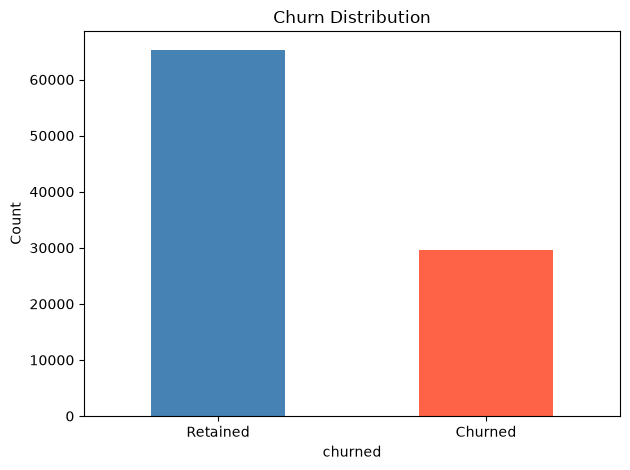

In [6]:
# Cell 2 — Churn rate
print(f"Churn rate: {y.mean():.1%}")
print(f"Churned: {y.sum():,} | Retained: {(1-y).sum():,}")

y.value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Churn Distribution')
plt.xticks([0,1], ['Retained', 'Churned'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../docs/churn_distribution.png')
plt.show()

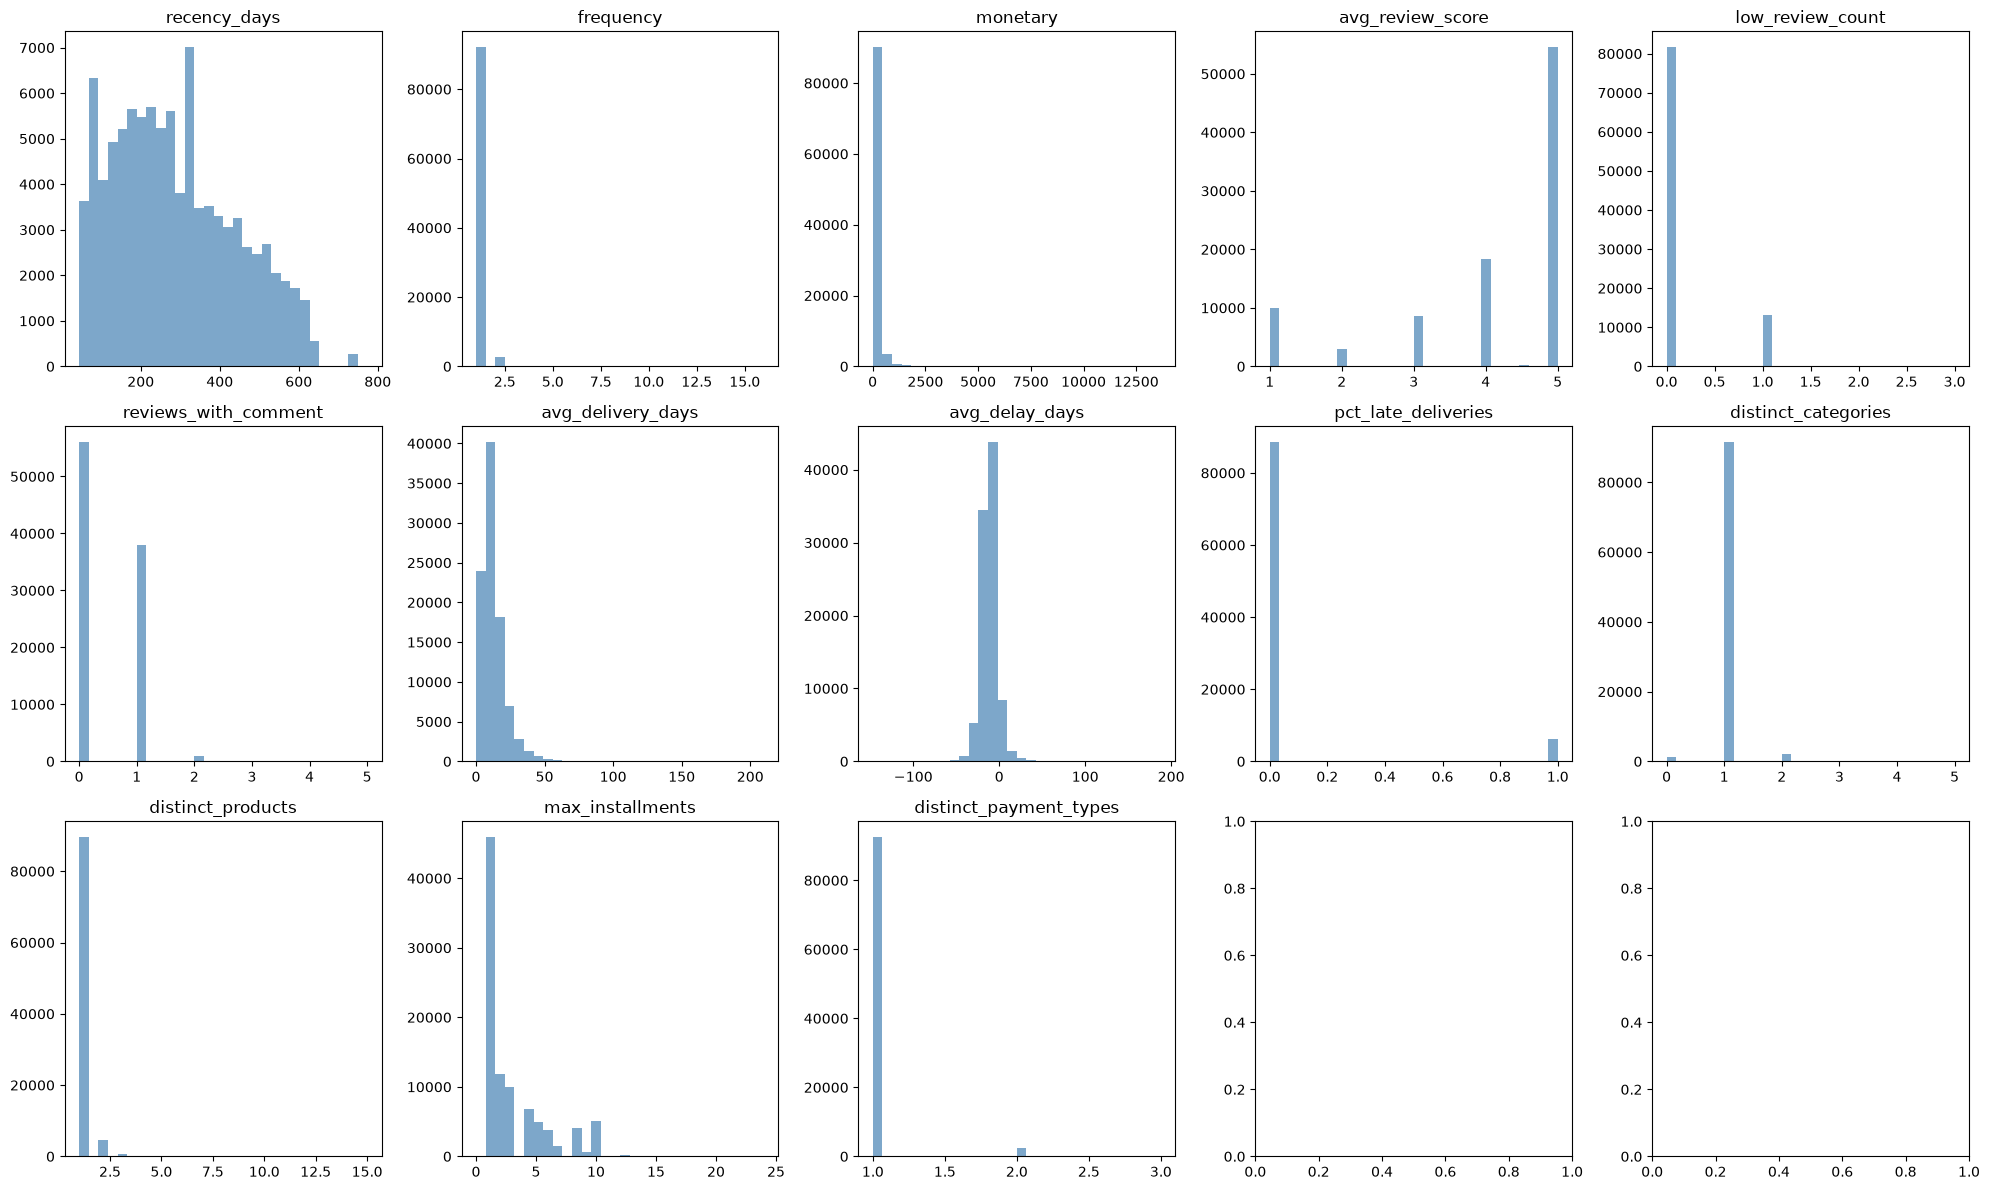

In [7]:
# Cell 3 — Feature distributions
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=30, color='steelblue', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('../docs/feature_distributions.png')
plt.show()

Feature correlations with churn:
recency_days              0.690
frequency                -0.238
avg_delivery_days         0.186
distinct_categories      -0.165
distinct_products        -0.158
avg_review_score         -0.069
avg_delay_days            0.063
pct_late_deliveries       0.060
monetary                 -0.038
low_review_count          0.034
distinct_payment_types   -0.026
reviews_with_comment     -0.015
max_installments          0.001
dtype: float64


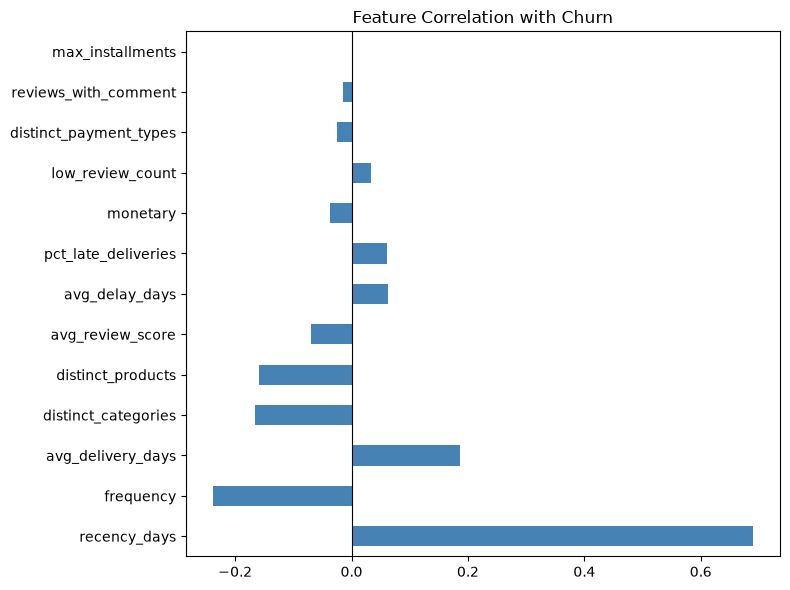

In [8]:
# Cell 4 — Feature correlation with churn
correlations = X.corrwith(y).sort_values(key=abs, ascending=False)
print("Feature correlations with churn:")
print(correlations.round(3))

correlations.plot(kind='barh', color='steelblue', figsize=(8,6))
plt.title('Feature Correlation with Churn')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../docs/feature_correlations.png')
plt.show()

In [9]:
# Cell 5 — Key business insight
print("Average features by churn status:")
df.groupby('churned')[X.columns].mean().round(2).T

Average features by churn status:


churned,False,True
recency_days,130.72,358.45
frequency,1.11,1.0
monetary,178.38,159.93
avg_review_score,4.24,4.04
low_review_count,0.13,0.15
reviews_with_comment,0.43,0.42
avg_delivery_days,9.63,13.5
avg_delay_days,-12.6,-11.21
pct_late_deliveries,0.04,0.08
distinct_categories,1.06,0.99
